In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv("Datasets/Social_Network_Ads (1).csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [7]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [8]:
df["Purchased"].unique()

array([0, 1])

In [9]:
df.drop("User ID", axis=1, inplace=True)

In [15]:
df= pd.get_dummies(df, drop_first=True)

In [16]:
df

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,True
1,35,20000,0,True
2,26,43000,0,False
3,27,57000,0,False
4,19,76000,0,True
...,...,...,...,...
395,46,41000,1,False
396,51,23000,1,True
397,50,20000,1,False
398,36,33000,0,True


In [17]:
y = df[["Purchased"]]

In [18]:
x= df.drop("Purchased", axis=1)

In [20]:
x.head()

,Age,EstimatedSalary,Gender_Male
0,19,19000,True
1,35,20000,True
2,26,43000,False
3,27,57000,False
4,19,76000,True


In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=70)

In [22]:
model = LinearRegression()

In [23]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
pred = model.predict(x_test)

In [25]:
pred

array([[ 0.56643094],
       [ 0.02366089],
       [ 0.74448599],
       [-0.17761009],
       [ 0.5288645 ],
       [-0.03727128],
       [ 0.12271424],
       [ 0.40138255],
       [ 0.41563862],
       [ 0.41671004],
       [ 0.41393981],
       [ 1.0376655 ],
       [ 0.43078811],
       [-0.09778122],
       [-0.00403497],
       [ 0.54239873],
       [ 0.17339269],
       [ 0.00575207],
       [ 0.68208835],
       [-0.18510449],
       [ 0.93763518],
       [ 0.6373662 ],
       [ 0.93957823],
       [ 0.44431146],
       [ 0.95774219],
       [ 0.3806926 ],
       [ 0.89493962],
       [ 0.98976818],
       [ 0.3098236 ],
       [-0.10488158],
       [ 0.07725936],
       [ 0.44431146],
       [ 0.54321501],
       [ 0.36146812],
       [ 0.41685984],
       [ 0.38566102],
       [ 0.53971206],
       [ 0.45946095],
       [ 0.92264638],
       [ 0.77389155],
       [ 0.52666631],
       [ 0.23350858],
       [ 0.40089406],
       [ 0.31439797],
       [ 0.35056521],
       [ 0

In [30]:
KNN = KNeighborsClassifier(n_neighbors=3)

In [31]:
KNN.fit(x_train,y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [32]:
y_pred = KNN.predict(x_test)

In [36]:
prediction = pd.DataFrame({"Actual":y_test.squeeze(), "Predicted":y_pred.squeeze()})

In [37]:
prediction

,Actual,Predicted
283,1,1
74,0,0
292,1,1
150,0,0
311,1,1
...,...,...
112,0,0
38,0,0
302,1,1
65,0,0


In [41]:
KNN.predict([[25, 30000,False]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1])

In [43]:
conf_matrix = confusion_matrix(y_test,y_pred)
conf_matrix

array([[45, 11],
       [ 3, 21]])

Text(50.722222222222214, 0.5, 'Actual')

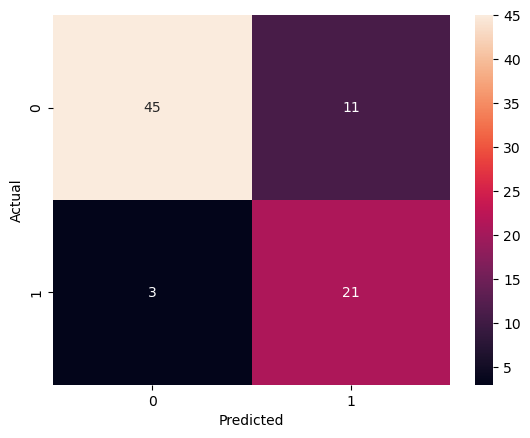

In [45]:
sns.heatmap(conf_matrix, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [48]:
TP = conf_matrix[0][0]
TN = conf_matrix[1][1]
FP = conf_matrix[0][1]
FN = conf_matrix[1][0]
print(TP, TN, FP, FN)
accuracy = (TP + TN) / np.sum(conf_matrix)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


45 21 11 3
Accuracy: 0.825
Precision: 0.8035714285714286
Recall: 0.9375
